### Deep learning model training.


In [1]:
import time
import torch
import random
import numpy as np 
import pandas as pd 
import torch.nn as nn
from glob import glob
from pyrsimg import imsShow
import matplotlib.pyplot as plt
import torch.nn.functional as F
from utils.utils import read_scenes
from torchvision.transforms import v2
from utils.data_aug import GaussianNoise
from utils.data_loader import SceneArraySet, PatchPathSet
from torchmetrics.classification import MulticlassJaccardIndex, BinaryAccuracy
from model import unet 


In [2]:
patch_size = 512        ## patch size setting
patch_resize = None     ## patch resize setting
learning_rate = 1e-4     
batch_size = 8   
device = torch.device('cuda:0')  


In [3]:
### traset
paths_scene_tra = sorted(glob('data/watset/ESWD/tra/scene/*'))
paths_truth_tra = sorted(glob('data/watset/ESWD/tra/truth/*'))
print(f'train_scenes: {len(paths_scene_tra)}')
## valset
paths_valset = sorted(glob(f'data/watset/ESWD/val_patch/*'))  ## for model prediction 
print(f'vali_patch_{patch_size}: {len(paths_valset)}')


train_scenes: 64
vali_patch_512: 178


### dataset loading

In [4]:
scenes_arr, truths_arr = read_scenes(paths_scene_tra, paths_truth_tra) 
scenes_arr = [scene_arr.astype(np.float32)/10000 for scene_arr in scenes_arr]   ## normalize the scenes array to the range [0, 1]
scene_truth_ls =  list(zip(scenes_arr, truths_arr))
scene_truth_ls = [np.concatenate([scene, truth[:, :, np.newaxis]], axis=-1) 
                                for scene, truth in scene_truth_ls] 


In [5]:
transforms_tra = v2.Compose([
      v2.ToImage(),
      v2.RandomCrop(size=(patch_size, patch_size), padding = 50, fill=0),
      v2.RandomApply([v2.RandomRotation(degrees=15)], p=0.3),
      v2.RandomHorizontalFlip(p=0.3),
      v2.RandomVerticalFlip(p=0.3),
      GaussianNoise(mean=0, sigma_max=0.1, p=0.3)    
       ])
transforms_val = v2.Compose([
      v2.ToDtype(torch.float32),
       ])


In [6]:
tra_dset = SceneArraySet(scene_truth_list = scene_truth_ls, transforms = transforms_tra)
val_dset = PatchPathSet(paths_valset=paths_valset, transforms=transforms_val)
### Create DataLoader
tra_loader = torch.utils.data.DataLoader(tra_dset, batch_size=batch_size, 
                                         shuffle=True, num_workers=4)
val_loader = torch.utils.data.DataLoader(val_dset, batch_size=batch_size, num_workers=5) 


#### Model training

In [7]:
### check model
model = unet(num_bands=6) 
model_name = 'unet'  ## model name for saving 


In [8]:
input_tensor = torch.randn(2, 6, 512, 512)  
output = model(input_tensor) 
print(output.shape)


torch.Size([2, 1, 512, 512])


In [9]:
### create loss and optimizer
bce_loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  
# lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, \
#                                       mode='max', 
#                                       factor=0.5, 
#                                       patience=10,
#                                       min_lr=1e-5)


In [10]:
sam_index = random.randrange(len(val_dset))
patch_val, truth_val = val_dset[sam_index]
def show_result(model, patch, truth):
    model.eval()
    device = next(model.parameters()).device
    patch, truth = patch.unsqueeze(0).to(device), truth.to(device)
    pred = model(patch) 
    ## convert to numpy and plot
    patch = patch[0].to('cpu').detach().numpy().transpose(1,2,0)            
    pred = pred[0].to('cpu').detach().numpy()
    truth = truth.to('cpu').detach().numpy()
    imsShow([patch, pred, truth],   
            clip_list = (2,0,0),
            img_name_list=['patch', 'pred', 'truth'], 
            color_bands_list=([3,2,2], 0, 0),                    
            figsize=(9, 2.5))
    plt.tight_layout() 
    plt.show()     

In [ ]:
'''------train loops------'''
def train_loops(model, loss_fn, 
                    optimizer, 
                    tra_loader, 
                    val_loader,  
                    epoches, 
                    device, 
                    lr_scheduler=None):
    loss_tra_loops, miou_tra_loops, oa_tra_loops = [], [], []
    loss_val_loops, miou_val_loops, oa_val_loops = [], [], []
    model = model.to(device)
    size_tra_loader = len(tra_loader)
    size_val_loader = len(val_loader)
    best_miou = 0.90   ## max miou
    epoches_i = []
    for epoch in range(epoches):
        start = time.time()
        loss_tra, loss_val = 0, 0
        '''-----train the model-----'''
        oa_tra = BinaryAccuracy().to(device)
        miou_tra = MulticlassJaccardIndex(num_classes=2, average="macro").to(device)
        model.train()   # training mode for dropout and batchnorm
        for x_batch, y_batch in tra_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            pred = (F.sigmoid(pred) > 0.5).float()
            miou_tra.update(pred, y_batch.long())
            oa_tra.update(pred, y_batch.long())
            loss_tra += loss.item()
        miou_tra_global = miou_tra.compute()
        oa_tra_global = oa_tra.compute()
        loss_tra_global = loss_tra/size_tra_loader
        miou_tra.reset(); oa_tra.reset()

        '''----- validation the model: time consuming -----'''
        oa_val = BinaryAccuracy().to(device)
        miou_val = MulticlassJaccardIndex(num_classes=2, average="macro").to(device)
        model.eval()
        if epoch > 0 and (epoch+1) % 2 == 0: 
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                with torch.no_grad():
                    pred = model(x_batch)
                    loss = loss_fn(pred, y_batch)
                pred = (F.sigmoid(pred) > 0.5).float()
                miou_val.update(pred, y_batch.long())
                oa_val.update(pred, y_batch.long())
                loss_val += loss.item()
            miou_val_global = miou_val.compute()
            oa_val_global = oa_val.compute()
            loss_val_global = loss_val/size_val_loader
            miou_val.reset(); oa_val.reset()
            loss_tra_loops.append(loss_tra_global); miou_tra_loops.append(miou_tra_global.item()); oa_tra_loops.append(oa_tra_global.item())
            loss_val_loops.append(loss_val_global); miou_val_loops.append(miou_val_global.item()); oa_val_loops.append(oa_val_global.item())
            epoches_i.append(epoch)
            print(f'Ep{epoch}: tra-> Loss:{loss_tra_global:.3f},Oa:{oa_tra_global:.3f},Miou:{miou_tra_global:.3f}, '
                    f'val-> Loss:{loss_val_global:.4f},Oa:{oa_val_global:.4f}, Miou:{miou_val_global:.4f},time:{time.time()-start:.1f}s')
            ## save the best model
            if miou_val_global.item() > best_miou:
                best_miou = miou_val_global.item()       ## update best miou
                torch.save(model.state_dict(), f'model/trained/{model_name}_0{str(round(best_miou*10000))}.pth')
        else:  ## 
            print(f'Ep{epoch}: tra-> Loss:{loss_tra_global:.3f},Oa:{oa_tra_global:.3f},Miou:{miou_tra_global:.3f}, \
                                time:{time.time()-start:.1f}s')
        if lr_scheduler: lr_scheduler.step(miou_tra_global)    ## if use lr_scheduler like ReduceLROnPlateau
        if (epoch+1)%20 == 0:
            sam_index = random.randrange(len(val_dset))
            patch_val, truth_val = val_dset[sam_index]
            show_result(model=model, patch=patch_val, truth=truth_val)
    metrics = {'epoch':epoches_i, 'tra_loss':loss_tra_loops, 'tra_oa': oa_tra_loops, 'tra_miou': miou_tra_loops,
                'val_loss': loss_val_loops, 'val_oa': oa_val_loops, 'val_miou': miou_val_loops}
    return metrics 

Ep0: tra-> Loss:0.608,Oa:0.715,Miou:0.494,                                 time:1.3s
Ep1: tra-> Loss:0.451,Oa:0.879,Miou:0.746, val-> Loss:0.6316,Oa:0.7968, Miou:0.3984,time:2.1s
Ep2: tra-> Loss:0.371,Oa:0.906,Miou:0.790,                                 time:1.0s
Ep3: tra-> Loss:0.355,Oa:0.902,Miou:0.773, val-> Loss:0.4562,Oa:0.7995, Miou:0.4065,time:2.1s
Ep4: tra-> Loss:0.305,Oa:0.931,Miou:0.834,                                 time:1.0s
Ep5: tra-> Loss:0.301,Oa:0.925,Miou:0.816, val-> Loss:0.2642,Oa:0.9719, Miou:0.9161,time:2.1s
Ep6: tra-> Loss:0.265,Oa:0.949,Miou:0.872,                                 time:1.0s
Ep7: tra-> Loss:0.265,Oa:0.937,Miou:0.842, val-> Loss:0.2086,Oa:0.9772, Miou:0.9322,time:2.1s
Ep8: tra-> Loss:0.268,Oa:0.930,Miou:0.829,                                 time:1.0s
Ep9: tra-> Loss:0.249,Oa:0.939,Miou:0.851, val-> Loss:0.2030,Oa:0.9677, Miou:0.9033,time:2.3s
Ep10: tra-> Loss:0.275,Oa:0.918,Miou:0.806,                                 time:1.1s
Ep11: tra-> Loss:0.

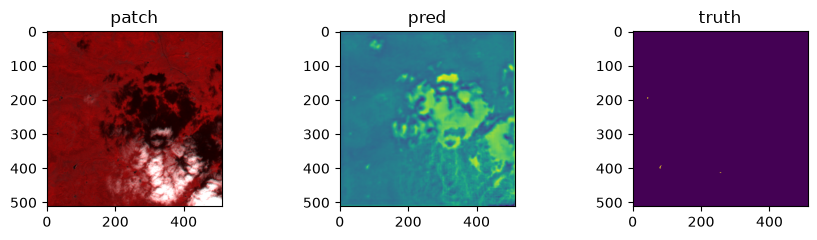

Ep20: tra-> Loss:0.174,Oa:0.954,Miou:0.882,                                 time:1.0s
Ep21: tra-> Loss:0.176,Oa:0.951,Miou:0.876, val-> Loss:0.1299,Oa:0.9743, Miou:0.9234,time:2.1s
Ep22: tra-> Loss:0.174,Oa:0.950,Miou:0.871,                                 time:1.0s
Ep23: tra-> Loss:0.167,Oa:0.953,Miou:0.877, val-> Loss:0.1226,Oa:0.9733, Miou:0.9207,time:2.2s
Ep24: tra-> Loss:0.148,Oa:0.960,Miou:0.901,                                 time:1.0s
Ep25: tra-> Loss:0.151,Oa:0.958,Miou:0.895, val-> Loss:0.1325,Oa:0.9691, Miou:0.9074,time:2.1s
Ep26: tra-> Loss:0.171,Oa:0.954,Miou:0.866,                                 time:0.9s
Ep27: tra-> Loss:0.146,Oa:0.956,Miou:0.893, val-> Loss:0.0942,Oa:0.9804, Miou:0.9422,time:2.1s
Ep28: tra-> Loss:0.158,Oa:0.949,Miou:0.868,                                 time:1.0s
Ep29: tra-> Loss:0.169,Oa:0.948,Miou:0.875, val-> Loss:0.0954,Oa:0.9800, Miou:0.9407,time:2.2s
Ep30: tra-> Loss:0.136,Oa:0.964,Miou:0.899,                                 time:1.0s
Ep31: tra

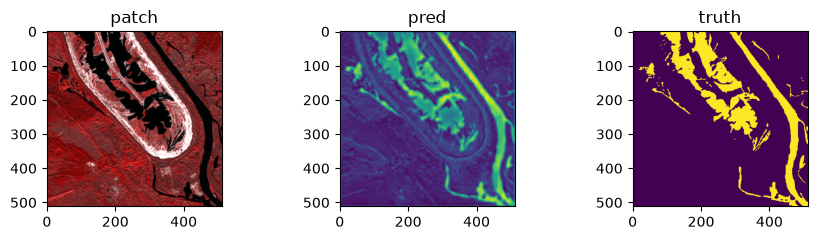

Ep40: tra-> Loss:0.150,Oa:0.951,Miou:0.865,                                 time:1.0s
Ep41: tra-> Loss:0.126,Oa:0.962,Miou:0.896, val-> Loss:0.0834,Oa:0.9788, Miou:0.9378,time:2.1s
Ep42: tra-> Loss:0.126,Oa:0.957,Miou:0.892,                                 time:1.0s
Ep43: tra-> Loss:0.146,Oa:0.949,Miou:0.862, val-> Loss:0.0901,Oa:0.9778, Miou:0.9336,time:2.1s
Ep44: tra-> Loss:0.115,Oa:0.964,Miou:0.902,                                 time:1.0s
Ep45: tra-> Loss:0.116,Oa:0.965,Miou:0.913, val-> Loss:0.0669,Oa:0.9845, Miou:0.9532,time:2.1s
Ep46: tra-> Loss:0.117,Oa:0.965,Miou:0.902,                                 time:1.0s
Ep47: tra-> Loss:0.125,Oa:0.959,Miou:0.892, val-> Loss:0.0700,Oa:0.9810, Miou:0.9441,time:2.1s
Ep48: tra-> Loss:0.134,Oa:0.954,Miou:0.874,                                 time:1.0s
Ep49: tra-> Loss:0.113,Oa:0.967,Miou:0.899, val-> Loss:0.0950,Oa:0.9726, Miou:0.9187,time:2.1s
Ep50: tra-> Loss:0.101,Oa:0.971,Miou:0.921,                                 time:1.0s
Ep51: tra

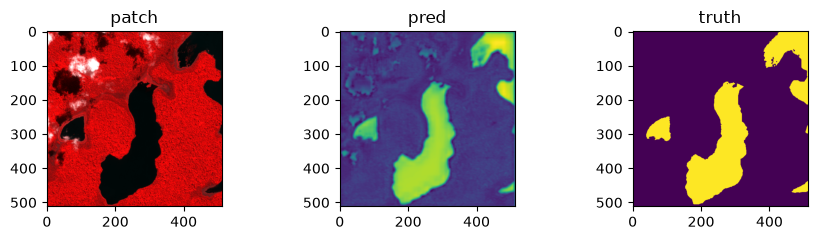

Ep60: tra-> Loss:0.097,Oa:0.971,Miou:0.922,                                 time:1.0s
Ep61: tra-> Loss:0.101,Oa:0.965,Miou:0.905, val-> Loss:0.0633,Oa:0.9849, Miou:0.9549,time:2.1s
Ep62: tra-> Loss:0.106,Oa:0.965,Miou:0.901,                                 time:1.0s
Ep63: tra-> Loss:0.099,Oa:0.967,Miou:0.916, val-> Loss:0.0563,Oa:0.9854, Miou:0.9562,time:2.3s
Ep64: tra-> Loss:0.110,Oa:0.962,Miou:0.891,                                 time:1.0s
Ep65: tra-> Loss:0.100,Oa:0.967,Miou:0.915, val-> Loss:0.0724,Oa:0.9751, Miou:0.9247,time:2.4s
Ep66: tra-> Loss:0.092,Oa:0.970,Miou:0.923,                                 time:1.1s
Ep67: tra-> Loss:0.094,Oa:0.968,Miou:0.918, val-> Loss:0.0635,Oa:0.9835, Miou:0.9508,time:2.2s
Ep68: tra-> Loss:0.084,Oa:0.975,Miou:0.930,                                 time:1.0s
Ep69: tra-> Loss:0.120,Oa:0.958,Miou:0.891, val-> Loss:0.0482,Oa:0.9866, Miou:0.9595,time:2.1s
Ep70: tra-> Loss:0.121,Oa:0.963,Miou:0.904,                                 time:1.0s
Ep71: tra

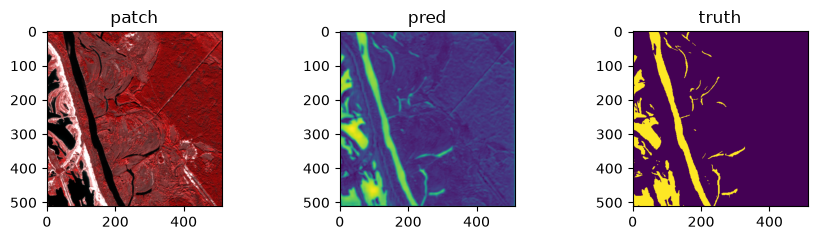

Ep80: tra-> Loss:0.094,Oa:0.968,Miou:0.911,                                 time:1.1s
Ep81: tra-> Loss:0.097,Oa:0.965,Miou:0.905, val-> Loss:0.0624,Oa:0.9820, Miou:0.9465,time:2.3s
Ep82: tra-> Loss:0.086,Oa:0.971,Miou:0.920,                                 time:1.0s
Ep83: tra-> Loss:0.078,Oa:0.975,Miou:0.928, val-> Loss:0.0611,Oa:0.9812, Miou:0.9447,time:2.3s
Ep84: tra-> Loss:0.132,Oa:0.948,Miou:0.852,                                 time:1.0s
Ep85: tra-> Loss:0.105,Oa:0.957,Miou:0.885, val-> Loss:0.0783,Oa:0.9721, Miou:0.9169,time:2.2s
Ep86: tra-> Loss:0.111,Oa:0.959,Miou:0.888,                                 time:1.0s
Ep87: tra-> Loss:0.082,Oa:0.974,Miou:0.922, val-> Loss:0.0766,Oa:0.9757, Miou:0.9273,time:2.2s
Ep88: tra-> Loss:0.091,Oa:0.970,Miou:0.920,                                 time:1.0s
Ep89: tra-> Loss:0.108,Oa:0.961,Miou:0.893, val-> Loss:0.0487,Oa:0.9839, Miou:0.9522,time:2.3s
Ep90: tra-> Loss:0.093,Oa:0.967,Miou:0.914,                                 time:1.0s
Ep91: tra

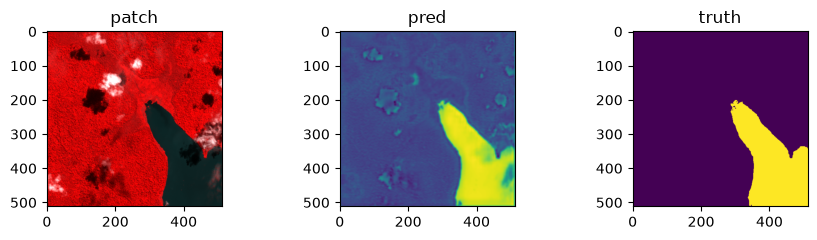

In [12]:
if __name__ == '__main__':
    metrics = train_loops(model=model,  
                    epoches=100,   
                    loss_fn=bce_loss,   
                    optimizer=optimizer,  
                    tra_loader=tra_loader,   
                    val_loader=val_loader,   
                    # lr_scheduler=lr_scheduler,   
                    device=device) 



In [13]:
# torch.save(model.state_dict(), f'model/trained/{model_name}_.pth')
# ## metrics saving
# path_metrics = f'model/trained/{model_name}_training_metrics.csv'
# metrics_df = pd.DataFrame(metrics)
# metrics_df.to_csv(path_metrics, index=False, sep=',')  
